Device: cpu
Processing Cars from cars...
Images processed: 45
Processing Cats from Data_100/Cats...
Images processed: 100
Processing Dogs from Data_100/Dogs...
Images processed: 100


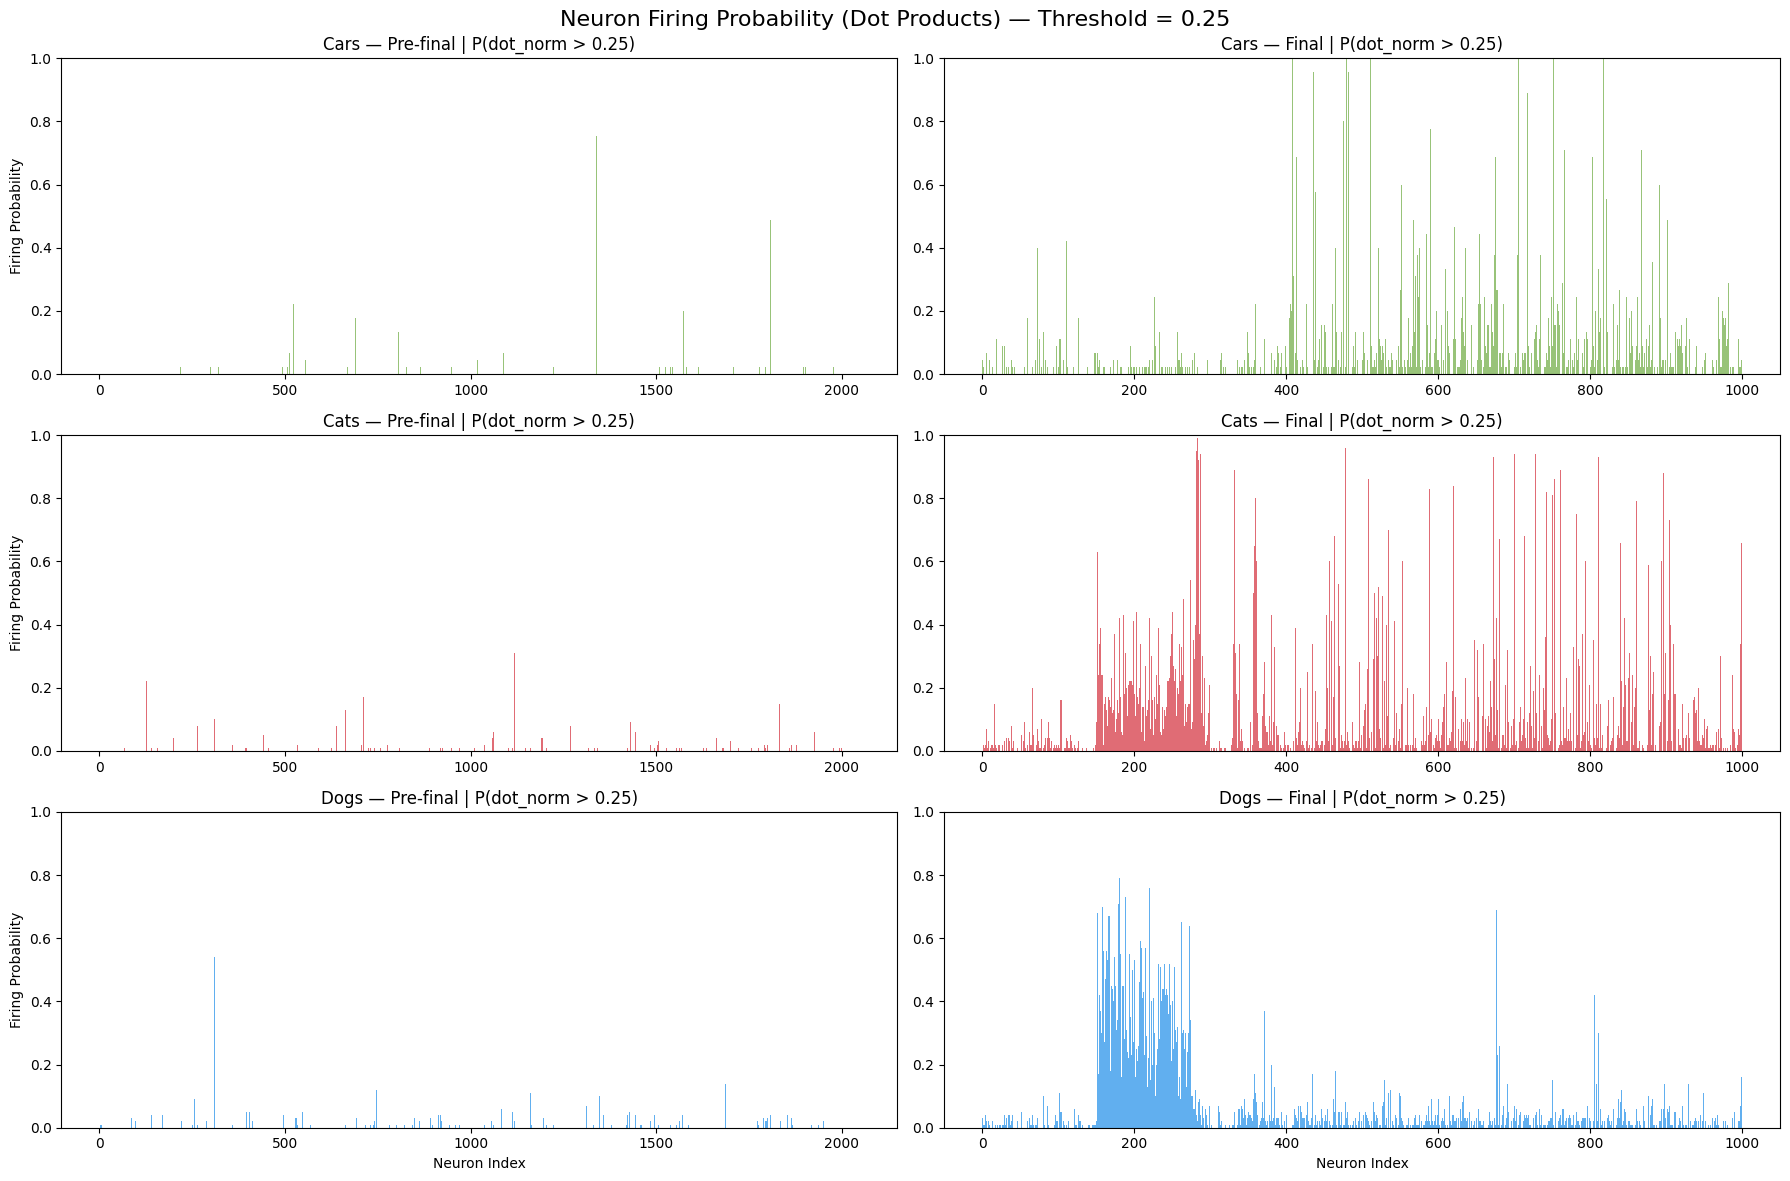

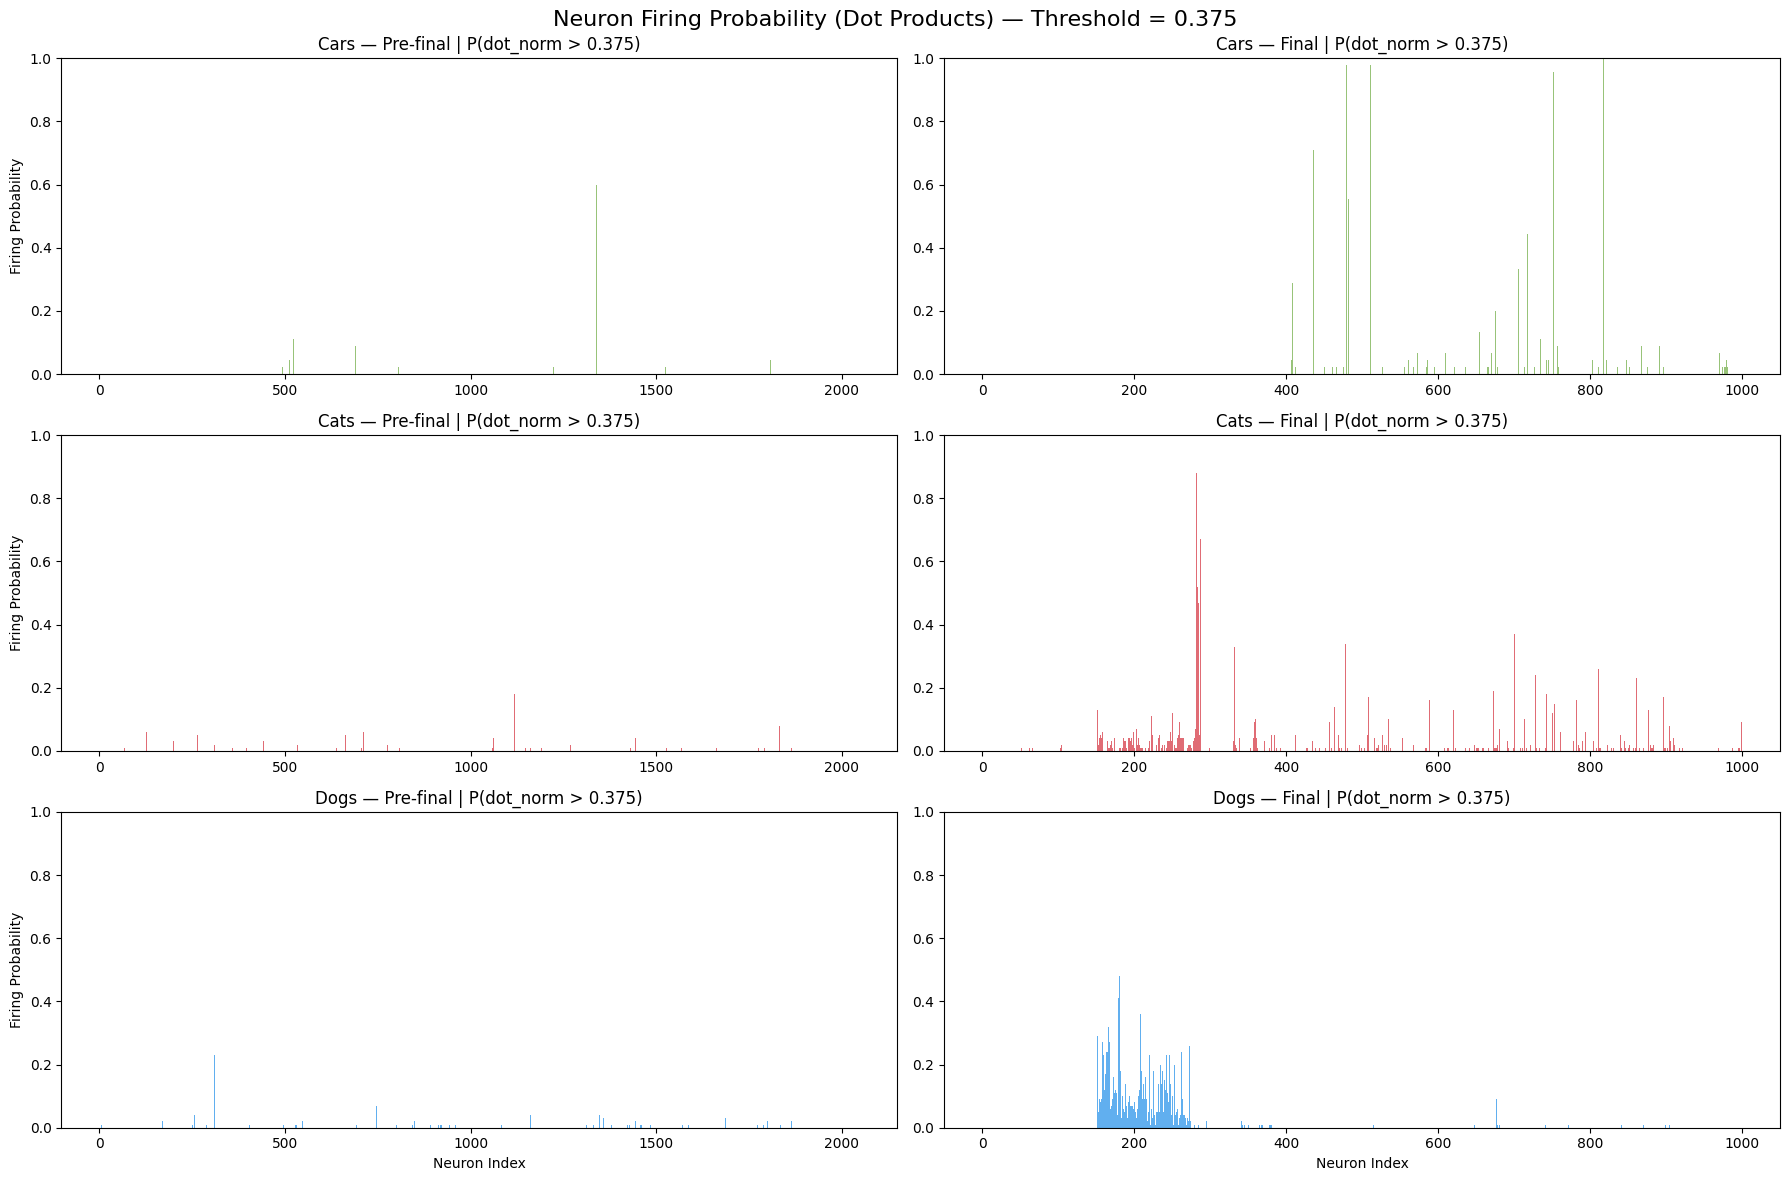

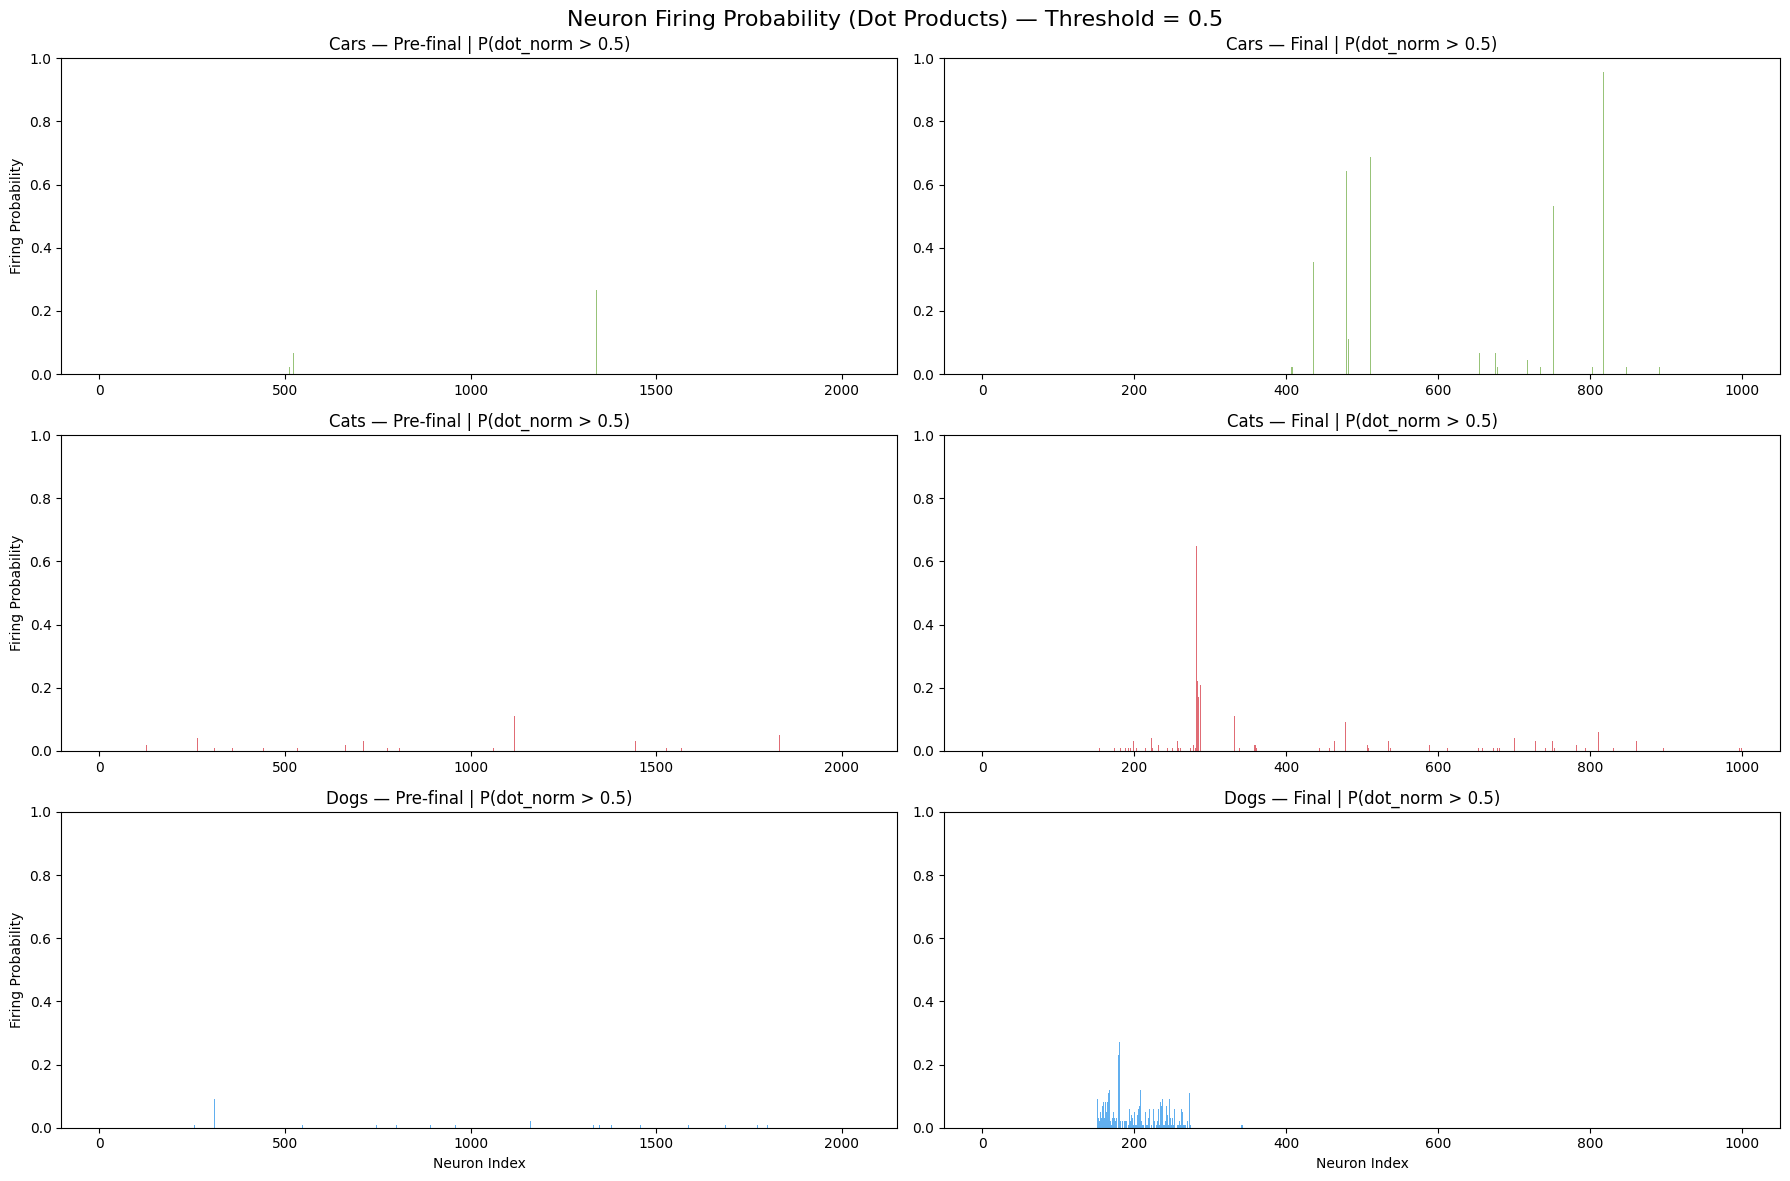

Done!


In [5]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

from torchvision import models, transforms
from PIL import Image


# ─── Dataset directories ─────────────────────────────────────────────────────

DATASETS = {
    "Cars": "cars",
    "Cats": "Data_100/Cats",
    "Dogs": "Data_100/Dogs"
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ─── Model & Hooks ───────────────────────────────────────────────────────────

def load_model():

    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    model.to(DEVICE)
    model.eval()

    activations = {"penultimate": []}

    def hook_penultimate(module, inp, out):
        flat = out.view(out.size(0), -1)
        activations["penultimate"].append(flat.detach().cpu().numpy())

    model.avgpool.register_forward_hook(hook_penultimate)

    # FC weights for dot product computation
    fc_weight = model.fc.weight.detach().cpu().numpy()  # [1000, 2048]

    return model, activations, fc_weight


# ─── Preprocessing ───────────────────────────────────────────────────────────

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])


# ─── Extract Activations ─────────────────────────────────────────────────────

def extract_all_activations(model, activations_dict):

    all_class_acts = {}

    for label, folder in DATASETS.items():

        print(f"Processing {label} from {folder}...")

        if not os.path.exists(folder):
            print(f"WARNING: Folder {folder} not found")
            continue

        files = sorted([
            f for f in os.listdir(folder)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])[:100]

        activations_dict["penultimate"] = []

        for fname in files:

            path = os.path.join(folder, fname)

            try:
                img = Image.open(path).convert("RGB")
                tensor = transform(img).unsqueeze(0).to(DEVICE)

                with torch.no_grad():
                    model(tensor)

            except Exception as e:
                print("Skipping", path, e)

        if activations_dict["penultimate"]:

            all_class_acts[label] = {
                "penultimate": np.concatenate(
                    activations_dict["penultimate"], axis=0
                )
            }

            print("Images processed:",
                  all_class_acts[label]["penultimate"].shape[0])

    return all_class_acts


# ─── Dot Product + Normalization + Firing Probability ───────────────────────

def get_dot_firing_probabilities(all_class_acts, fc_weight,
                                 thresholds):

    prob_results = {t: {} for t in thresholds}

    all_pen = []
    all_fin = []

    per_class_pen = {}
    per_class_fin = {}

    # -----------------------------
    # Compute dot products
    # -----------------------------
    for label, acts in all_class_acts.items():

        pen = acts["penultimate"]            # [N, 2048]
        fin = pen @ fc_weight.T              # [N, 1000]

        per_class_pen[label] = pen
        per_class_fin[label] = fin

        all_pen.append(pen)
        all_fin.append(fin)

    all_pen = np.concatenate(all_pen, axis=0)
    all_fin = np.concatenate(all_fin, axis=0)

    # -----------------------------
    # GLOBAL NORMALIZATION
    # -----------------------------
    pen_max = max(all_pen.max(), 1e-6)

    fin_min = all_fin.min()
    fin_max = all_fin.max()
    fin_range = max(fin_max - fin_min, 1e-6)

    # -----------------------------
    # FIRING PROBABILITY
    # -----------------------------
    for label in per_class_pen.keys():

        norm_pen = per_class_pen[label] / pen_max
        norm_fin = (per_class_fin[label] - fin_min) / fin_range

        for t in thresholds:
            prob_results[t][label] = {
                "penultimate": (norm_pen > t).mean(axis=0),
                "final": (norm_fin > t).mean(axis=0)
            }

    return prob_results


# ─── Plotting (Side by Side like original) ───────────────────────────────────

def plot_probability_comparison(prob_results):

    colors = {
        "Cars": "#98C379",
        "Cats": "#E06C75",
        "Dogs": "#61AFEF"
    }

    for threshold, class_data in prob_results.items():

        labels = list(class_data.keys())
        n_classes = len(labels)

        fig, axes = plt.subplots(
            n_classes, 2, figsize=(18, 4 * n_classes)
        )

        if n_classes == 1:
            axes = np.expand_dims(axes, axis=0)

        for i, label in enumerate(labels):

            color = colors.get(label, "#ABB2BF")

            pen = class_data[label]["penultimate"]
            fin = class_data[label]["final"]

            ax_p = axes[i, 0]
            ax_f = axes[i, 1]

            # Penultimate
            ax_p.bar(
                np.arange(len(pen)),
                pen,
                color=color,
                width=1.0
            )
            ax_p.set_title(
                f"{label} — Pre-final | P(dot_norm > {threshold})"
            )
            ax_p.set_ylabel("Firing Probability")
            ax_p.set_ylim(0, 1)

            # Final
            ax_f.bar(
                np.arange(len(fin)),
                fin,
                color=color,
                width=1.0
            )
            ax_f.set_title(
                f"{label} — Final | P(dot_norm > {threshold})"
            )
            ax_f.set_ylim(0, 1)

            if i == n_classes - 1:
                ax_p.set_xlabel("Neuron Index")
                ax_f.set_xlabel("Neuron Index")

        plt.suptitle(
            f"Neuron Firing Probability (Dot Products) — Threshold = {threshold}",
            fontsize=16
        )

        plt.tight_layout()
        plt.show()
        plt.close()


# ─── Main ────────────────────────────────────────────────────────────────────

def main():

    print("Device:", DEVICE)

    model, act_dict, fc_weight = load_model()

    all_class_acts = extract_all_activations(model, act_dict)

    if not all_class_acts:
        print("No activations extracted")
        return

    prob_results = get_dot_firing_probabilities(
        all_class_acts,
        fc_weight,
        thresholds=[0.25, 0.375, 0.5]
    )

    plot_probability_comparison(prob_results)

    print("Done!")


if __name__ == "__main__":
    main()


Device: cpu
Processing Cars from cars...
Images processed: 45
Processing Cats from Data_100/Cats...
Images processed: 100
Processing Dogs from Data_100/Dogs...
Images processed: 100


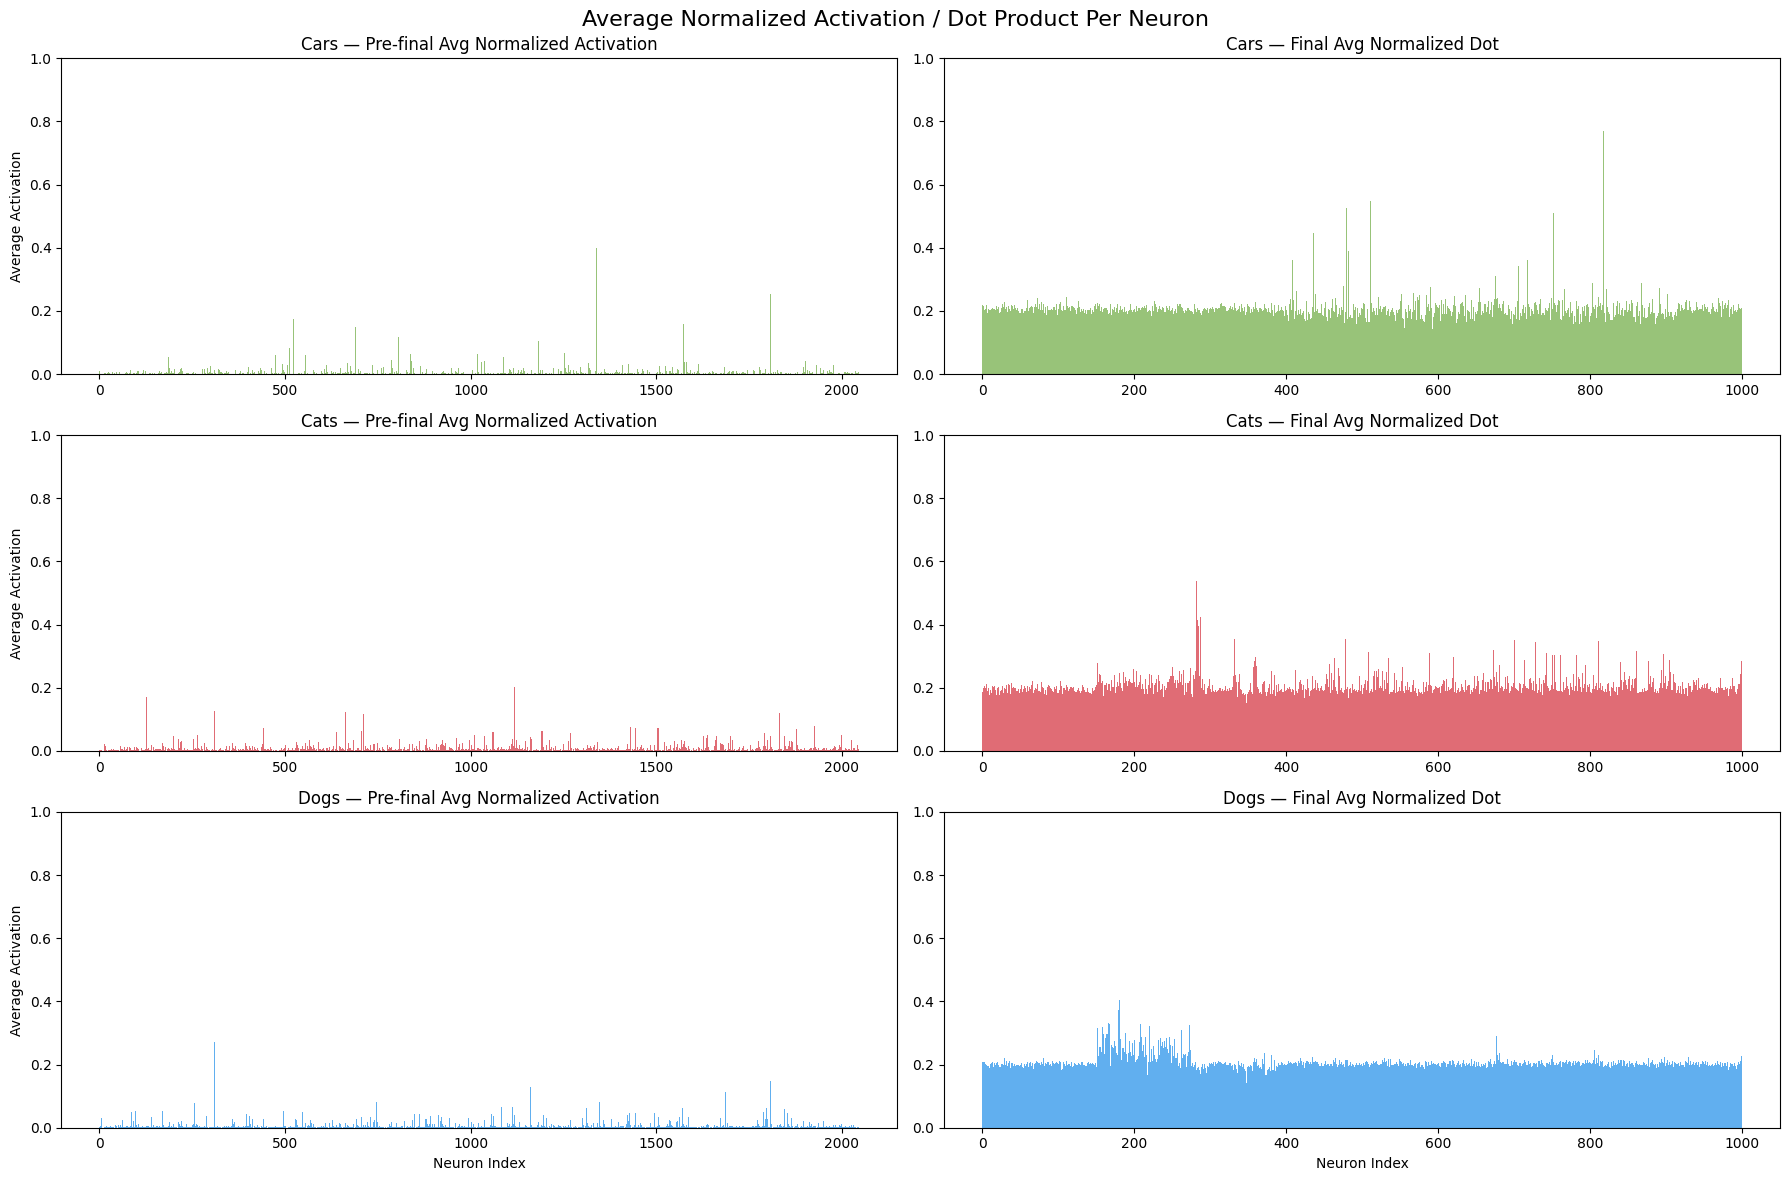

Done!


In [6]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

from torchvision import models, transforms
from PIL import Image


# ─── Dataset directories ─────────────────────────────────────────────────────

DATASETS = {
    "Cars": "cars",
    "Cats": "Data_100/Cats",
    "Dogs": "Data_100/Dogs"
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ─── Model & Hooks ───────────────────────────────────────────────────────────

def load_model():

    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    model.to(DEVICE)
    model.eval()

    activations = {"penultimate": []}

    def hook_penultimate(module, inp, out):
        flat = out.view(out.size(0), -1)
        activations["penultimate"].append(flat.detach().cpu().numpy())

    model.avgpool.register_forward_hook(hook_penultimate)

    fc_weight = model.fc.weight.detach().cpu().numpy()  # [1000, 2048]

    return model, activations, fc_weight


# ─── Preprocessing ───────────────────────────────────────────────────────────

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])


# ─── Extract Activations ─────────────────────────────────────────────────────

def extract_all_activations(model, activations_dict):

    all_class_acts = {}

    for label, folder in DATASETS.items():

        print(f"Processing {label} from {folder}...")

        if not os.path.exists(folder):
            print(f"WARNING: Folder {folder} not found")
            continue

        files = sorted([
            f for f in os.listdir(folder)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])[:100]

        activations_dict["penultimate"] = []

        for fname in files:

            path = os.path.join(folder, fname)

            try:
                img = Image.open(path).convert("RGB")
                tensor = transform(img).unsqueeze(0).to(DEVICE)

                with torch.no_grad():
                    model(tensor)

            except Exception as e:
                print("Skipping", path, e)

        if activations_dict["penultimate"]:

            all_class_acts[label] = {
                "penultimate": np.concatenate(
                    activations_dict["penultimate"], axis=0
                )
            }

            print("Images processed:",
                  all_class_acts[label]["penultimate"].shape[0])

    return all_class_acts


# ─── Dot Product + Normalization + Average Activation ───────────────────────

def get_average_normalized_activation(all_class_acts, fc_weight):

    results = {}

    all_pen = []
    all_fin = []

    per_class_pen = {}
    per_class_fin = {}

    # -----------------------------
    # Compute dot products
    # -----------------------------
    for label, acts in all_class_acts.items():

        pen = acts["penultimate"]            # [N, 2048]
        fin = pen @ fc_weight.T              # [N, 1000]

        per_class_pen[label] = pen
        per_class_fin[label] = fin

        all_pen.append(pen)
        all_fin.append(fin)

    all_pen = np.concatenate(all_pen, axis=0)
    all_fin = np.concatenate(all_fin, axis=0)

    # -----------------------------
    # GLOBAL NORMALIZATION
    # -----------------------------
    pen_max = max(all_pen.max(), 1e-6)

    fin_min = all_fin.min()
    fin_max = all_fin.max()
    fin_range = max(fin_max - fin_min, 1e-6)

    # -----------------------------
    # AVERAGE NORMALIZED ACTIVATION
    # -----------------------------
    for label in per_class_pen.keys():

        norm_pen = per_class_pen[label] / pen_max
        norm_fin = (per_class_fin[label] - fin_min) / fin_range

        results[label] = {
            "penultimate": norm_pen.mean(axis=0),
            "final": norm_fin.mean(axis=0)
        }

    return results


# ─── Plotting ────────────────────────────────────────────────────────────────

def plot_average_activation(results):

    colors = {
        "Cars": "#98C379",
        "Cats": "#E06C75",
        "Dogs": "#61AFEF"
    }

    labels = list(results.keys())
    n_classes = len(labels)

    fig, axes = plt.subplots(
        n_classes, 2, figsize=(18, 4 * n_classes)
    )

    if n_classes == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, label in enumerate(labels):

        color = colors.get(label, "#ABB2BF")

        pen = results[label]["penultimate"]
        fin = results[label]["final"]

        ax_p = axes[i, 0]
        ax_f = axes[i, 1]

        # Pre-final
        ax_p.bar(np.arange(len(pen)), pen, color=color, width=1.0)
        ax_p.set_title(f"{label} — Pre-final Avg Normalized Activation")
        ax_p.set_ylabel("Average Activation")
        ax_p.set_ylim(0, 1)

        # Final
        ax_f.bar(np.arange(len(fin)), fin, color=color, width=1.0)
        ax_f.set_title(f"{label} — Final Avg Normalized Dot")
        ax_f.set_ylim(0, 1)

        if i == n_classes - 1:
            ax_p.set_xlabel("Neuron Index")
            ax_f.set_xlabel("Neuron Index")

    plt.suptitle(
        "Average Normalized Activation / Dot Product Per Neuron",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()
    plt.close()


# ─── Main ────────────────────────────────────────────────────────────────────

def main():

    print("Device:", DEVICE)

    model, act_dict, fc_weight = load_model()

    all_class_acts = extract_all_activations(model, act_dict)

    if not all_class_acts:
        print("No activations extracted")
        return

    results = get_average_normalized_activation(
        all_class_acts,
        fc_weight
    )

    plot_average_activation(results)

    print("Done!")


if __name__ == "__main__":
    main()


Device: cpu
Processing Cars from cars...
Images processed: 45
Processing Cats from Data_100/Cats...
Images processed: 100
Processing Dogs from Data_100/Dogs...
Images processed: 100


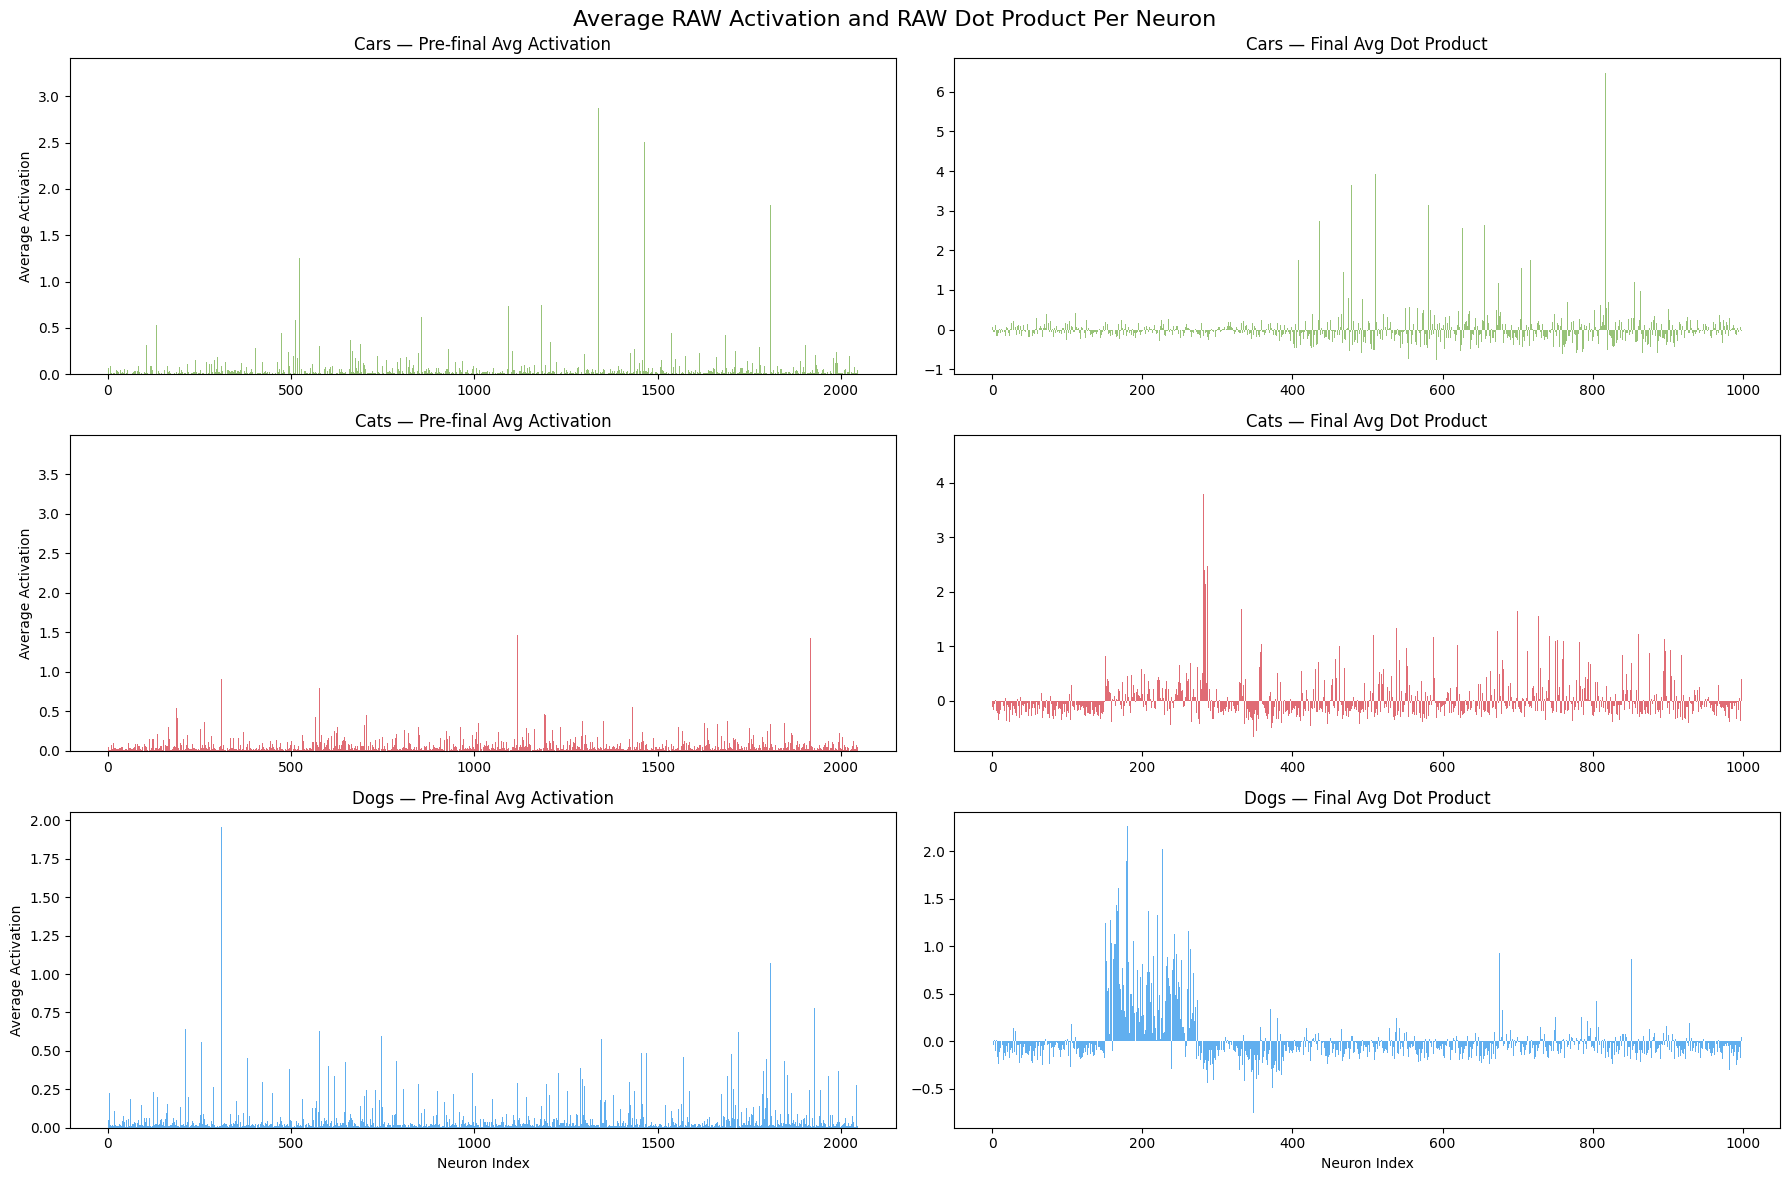

Done!


In [7]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

from torchvision import models, transforms
from PIL import Image


# ─── Dataset directories ─────────────────────────────────────────────────────

DATASETS = {
    "Cars": "cars",
    "Cats": "Data_100/Cats",
    "Dogs": "Data_100/Dogs"
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ─── Model & Hooks ───────────────────────────────────────────────────────────

def load_model():

    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    model.to(DEVICE)
    model.eval()

    activations = {"penultimate": []}

    def hook_penultimate(module, inp, out):
        flat = out.view(out.size(0), -1)
        activations["penultimate"].append(flat.detach().cpu().numpy())

    model.avgpool.register_forward_hook(hook_penultimate)

    # FC weights for dot products
    fc_weight = model.fc.weight.detach().cpu().numpy()   # [1000, 2048]

    return model, activations, fc_weight


# ─── Preprocessing ───────────────────────────────────────────────────────────

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])


# ─── Extract Activations ─────────────────────────────────────────────────────

def extract_all_activations(model, activations_dict):

    all_class_acts = {}

    for label, folder in DATASETS.items():

        print(f"Processing {label} from {folder}...")

        if not os.path.exists(folder):
            print(f"WARNING: Folder {folder} not found")
            continue

        files = sorted([
            f for f in os.listdir(folder)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])[:100]

        activations_dict["penultimate"] = []

        for fname in files:

            path = os.path.join(folder, fname)

            try:
                img = Image.open(path).convert("RGB")
                tensor = transform(img).unsqueeze(0).to(DEVICE)

                with torch.no_grad():
                    model(tensor)

            except Exception as e:
                print("Skipping", path, e)

        if activations_dict["penultimate"]:

            all_class_acts[label] = {
                "penultimate": np.concatenate(
                    activations_dict["penultimate"], axis=0
                )
            }

            print("Images processed:",
                  all_class_acts[label]["penultimate"].shape[0])

    return all_class_acts


# ─── Raw Average Activation + Raw Dot Products ──────────────────────────────

def get_average_raw_values(all_class_acts, fc_weight):

    results = {}

    for label, acts in all_class_acts.items():

        pen = acts["penultimate"]            # [N, 2048]
        fin = pen @ fc_weight.T              # [N, 1000]

        results[label] = {
            "penultimate": pen.mean(axis=0),   # raw avg activation
            "final": fin.mean(axis=0)          # raw avg dot product
        }

    return results


# ─── Plotting ────────────────────────────────────────────────────────────────

def plot_average_raw(results):

    colors = {
        "Cars": "#98C379",
        "Cats": "#E06C75",
        "Dogs": "#61AFEF"
    }

    labels = list(results.keys())
    n_classes = len(labels)

    fig, axes = plt.subplots(
        n_classes, 2, figsize=(18, 4 * n_classes)
    )

    if n_classes == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, label in enumerate(labels):

        color = colors.get(label, "#ABB2BF")

        pen = results[label]["penultimate"]
        fin = results[label]["final"]

        ax_p = axes[i, 0]
        ax_f = axes[i, 1]

        # Pre-final
        ax_p.bar(np.arange(len(pen)), pen, color=color, width=1.0)
        ax_p.set_title(f"{label} — Pre-final Avg Activation")
        ax_p.set_ylabel("Average Activation")

        # Final
        ax_f.bar(np.arange(len(fin)), fin, color=color, width=1.0)
        ax_f.set_title(f"{label} — Final Avg Dot Product")

        if i == n_classes - 1:
            ax_p.set_xlabel("Neuron Index")
            ax_f.set_xlabel("Neuron Index")

    plt.suptitle(
        "Average RAW Activation and RAW Dot Product Per Neuron",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()
    plt.close()


# ─── Main ────────────────────────────────────────────────────────────────────

def main():

    print("Device:", DEVICE)

    model, act_dict, fc_weight = load_model()

    all_class_acts = extract_all_activations(model, act_dict)

    if not all_class_acts:
        print("No activations extracted")
        return

    results = get_average_raw_values(
        all_class_acts,
        fc_weight
    )

    plot_average_raw(results)

    print("Done!")


if __name__ == "__main__":
    main()



Device: cpu
Processing Cars from cars...
Images processed: 45
Processing Cats from Data_100/Cats...
Images processed: 100
Processing Dogs from Data_100/Dogs...
Images processed: 100


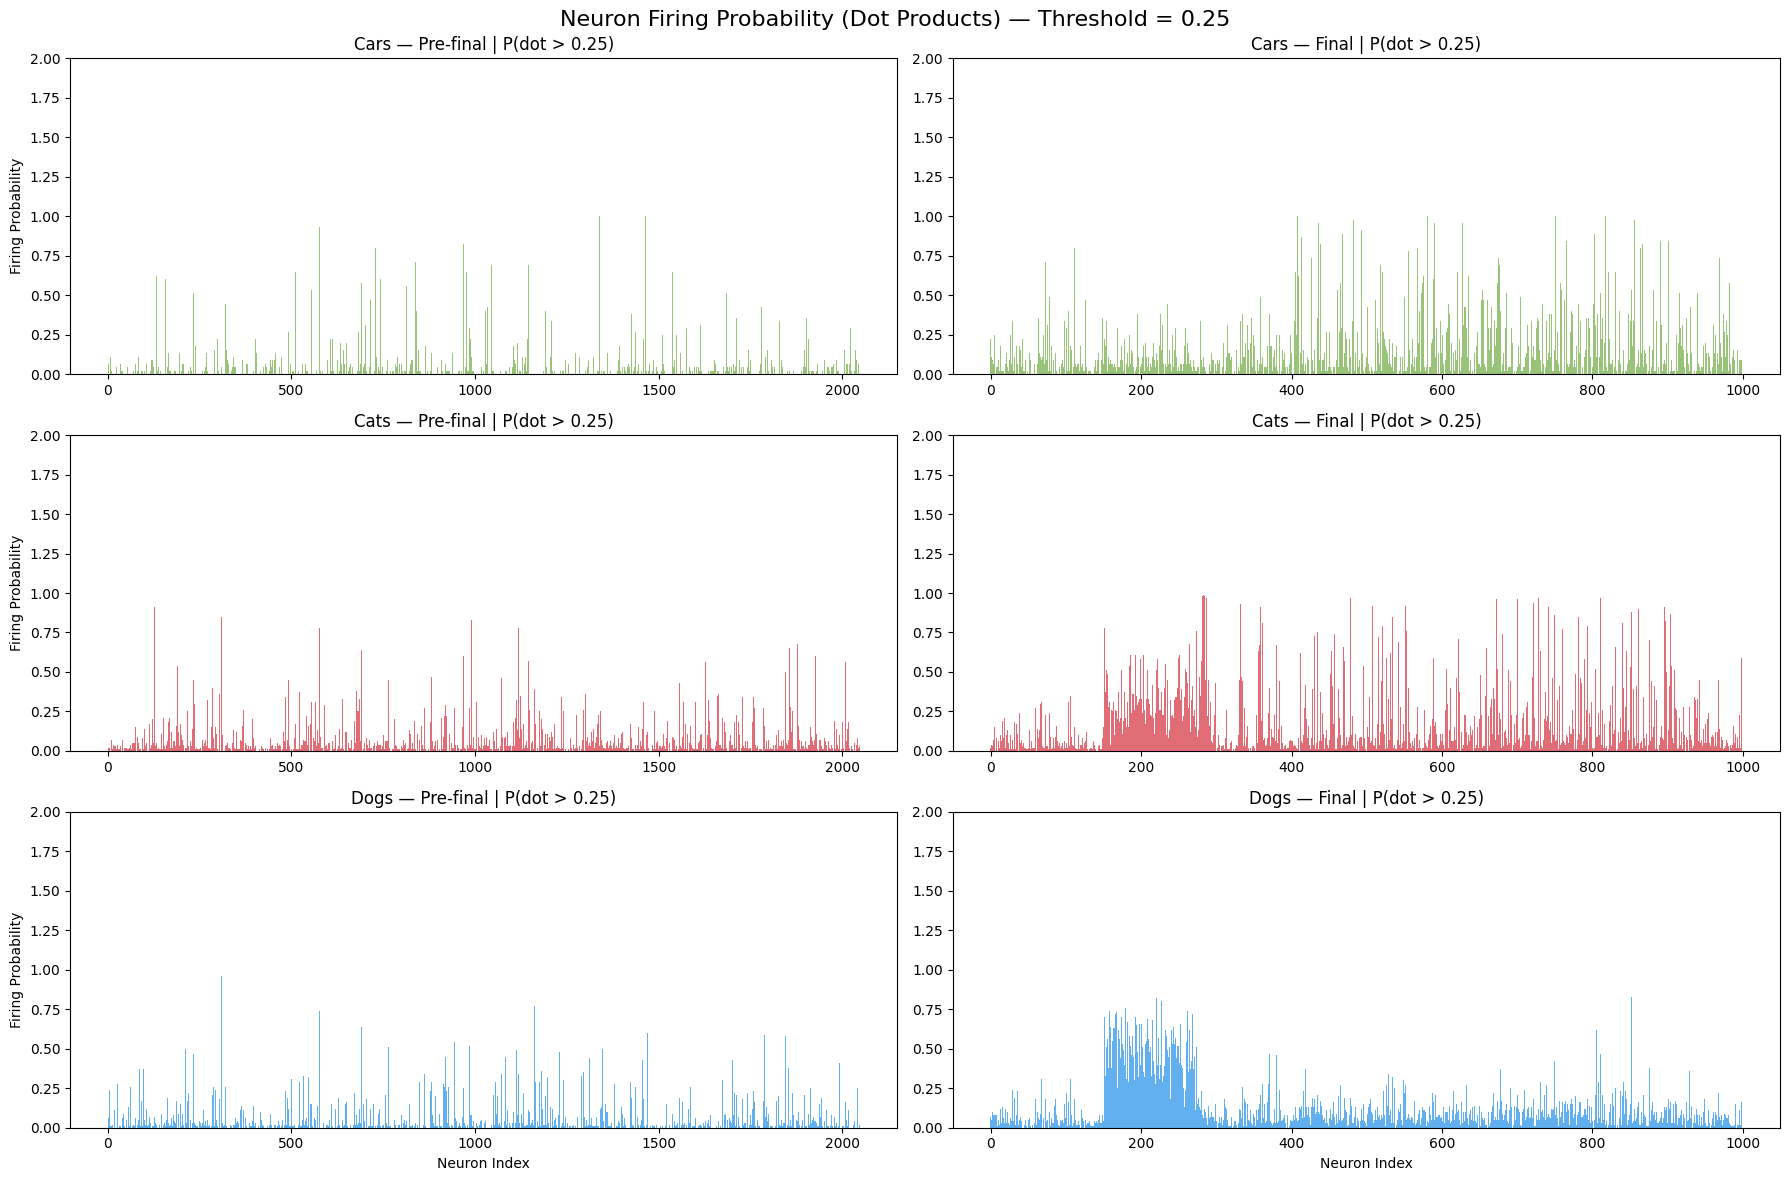

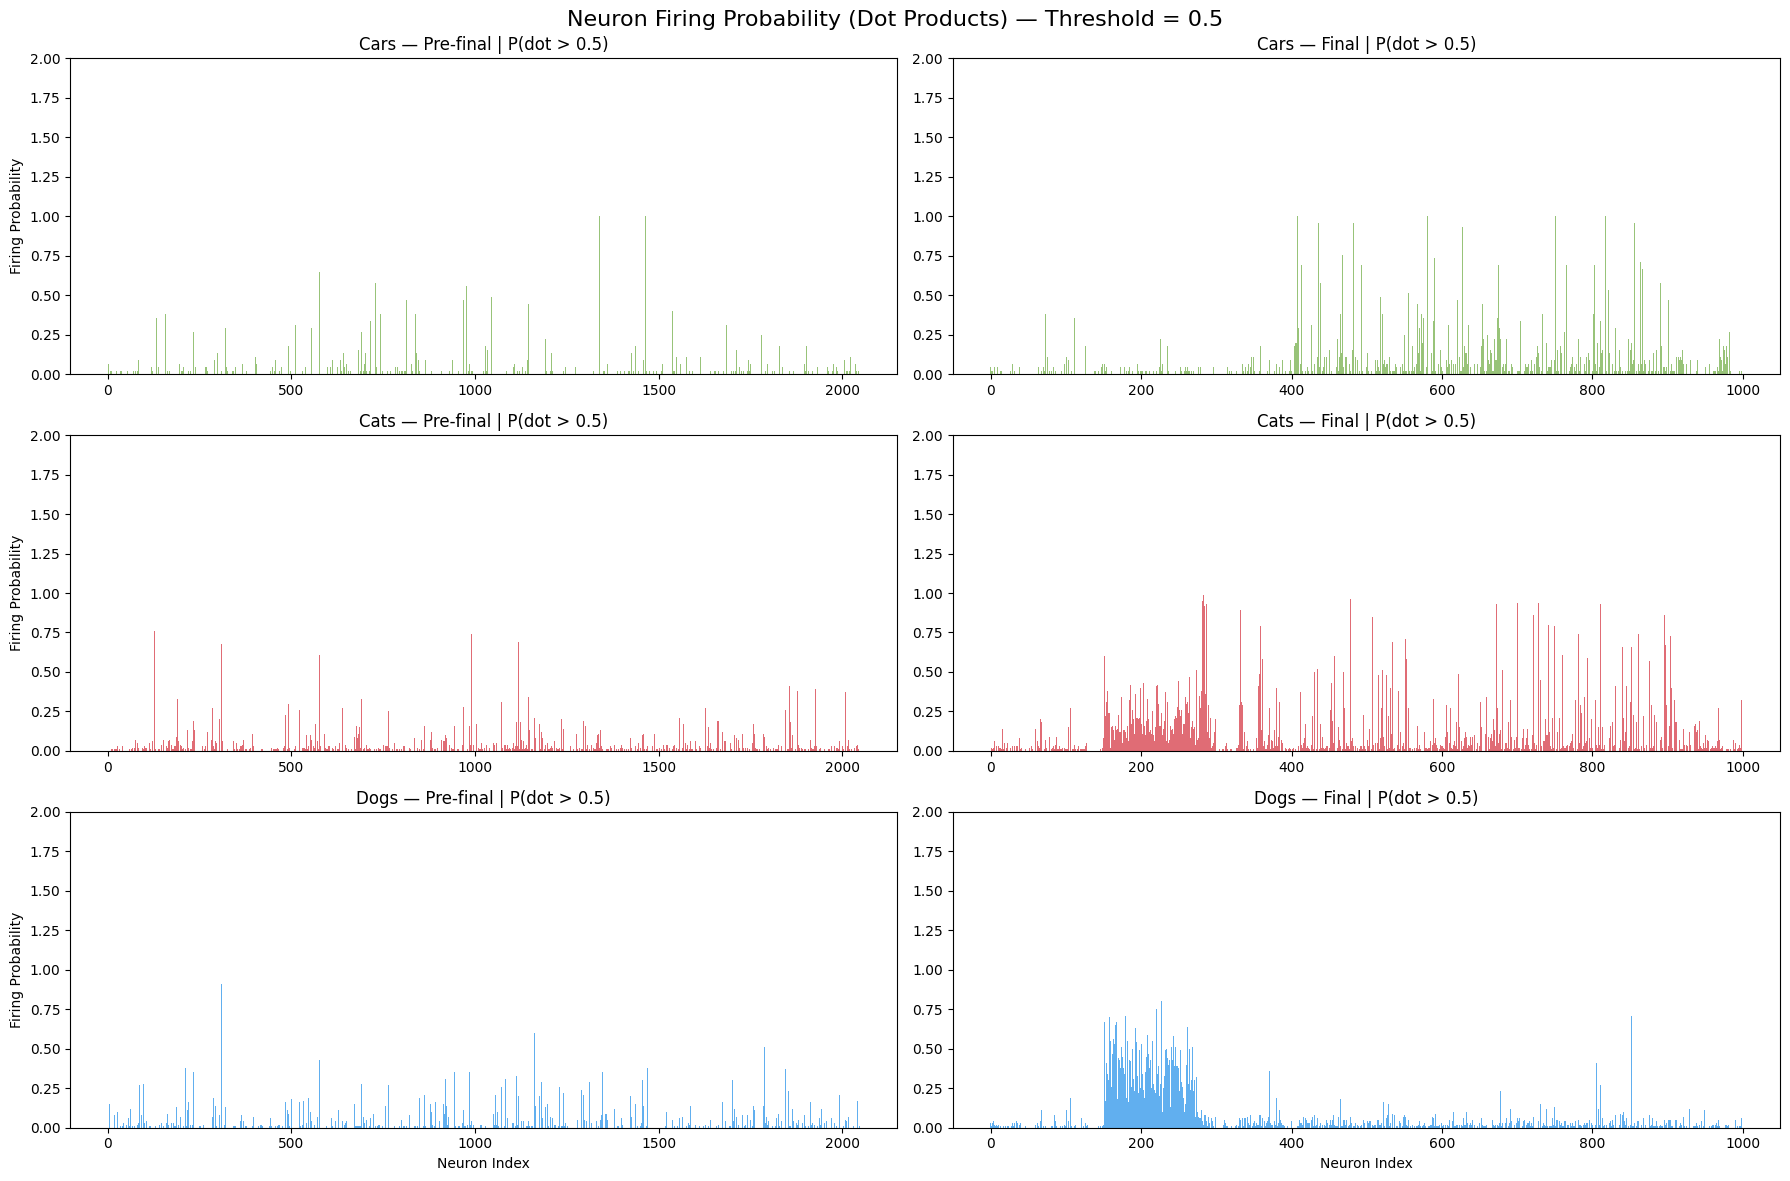

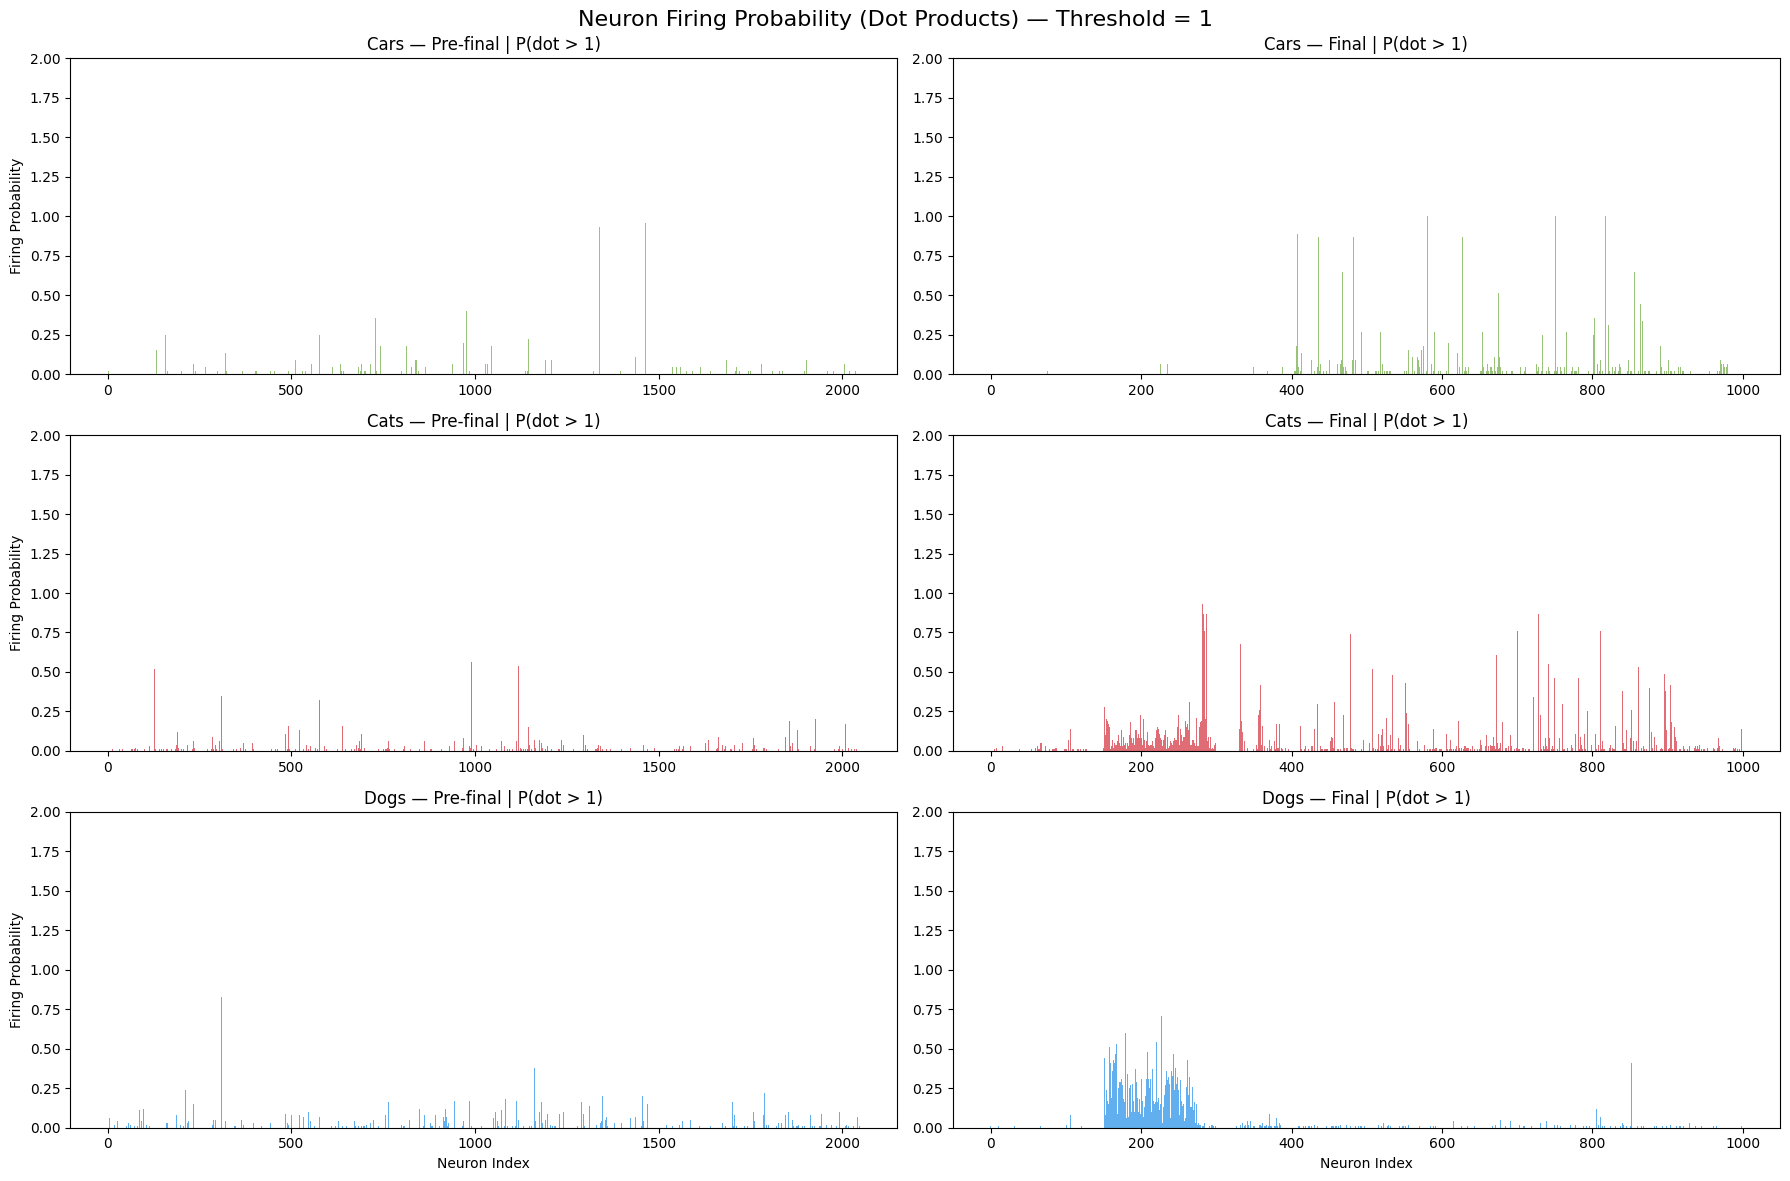

Done!


In [13]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

from torchvision import models, transforms
from PIL import Image


# ─── Dataset directories ─────────────────────────────────────────────────────

DATASETS = {
    "Cars": "cars",
    "Cats": "Data_100/Cats",
    "Dogs": "Data_100/Dogs"
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ─── Model & Hooks ───────────────────────────────────────────────────────────

def load_model():

    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    model.to(DEVICE)
    model.eval()

    activations = {"penultimate": []}

    def hook_penultimate(module, inp, out):
        flat = out.view(out.size(0), -1)
        activations["penultimate"].append(flat.detach().cpu().numpy())

    model.avgpool.register_forward_hook(hook_penultimate)

    # FC weights for dot product computation
    fc_weight = model.fc.weight.detach().cpu().numpy()  # [1000, 2048]

    return model, activations, fc_weight


# ─── Preprocessing ───────────────────────────────────────────────────────────

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])


# ─── Extract Activations ─────────────────────────────────────────────────────

def extract_all_activations(model, activations_dict):

    all_class_acts = {}

    for label, folder in DATASETS.items():

        print(f"Processing {label} from {folder}...")

        if not os.path.exists(folder):
            print(f"WARNING: Folder {folder} not found")
            continue

        files = sorted([
            f for f in os.listdir(folder)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])[:100]

        activations_dict["penultimate"] = []

        for fname in files:

            path = os.path.join(folder, fname)

            try:
                img = Image.open(path).convert("RGB")
                tensor = transform(img).unsqueeze(0).to(DEVICE)

                with torch.no_grad():
                    model(tensor)

            except Exception as e:
                print("Skipping", path, e)

        if activations_dict["penultimate"]:

            all_class_acts[label] = {
                "penultimate": np.concatenate(
                    activations_dict["penultimate"], axis=0
                )
            }

            print("Images processed:",
                  all_class_acts[label]["penultimate"].shape[0])

    return all_class_acts


# ─── Dot Product + Normalization + Firing Probability ───────────────────────

def get_dot_firing_probabilities(all_class_acts, fc_weight,
                                 thresholds):

    prob_results = {t: {} for t in thresholds}

    all_pen = []
    all_fin = []

    per_class_pen = {}
    per_class_fin = {}

    # -----------------------------
    # Compute dot products
    # -----------------------------
    for label, acts in all_class_acts.items():

        pen = acts["penultimate"]            # [N, 2048]
        fin = pen @ fc_weight.T              # [N, 1000]

        per_class_pen[label] = pen
        per_class_fin[label] = fin

        all_pen.append(pen)
        all_fin.append(fin)

    all_pen = np.concatenate(all_pen, axis=0)
    all_fin = np.concatenate(all_fin, axis=0)

    # -----------------------------
    # GLOBAL NORMALIZATION
    # -----------------------------

    # -----------------------------
    # FIRING PROBABILITY
    # -----------------------------
    for label in per_class_pen.keys():

        norm_pen = per_class_pen[label]
        norm_fin = (per_class_fin[label]) 

        for t in thresholds:
            prob_results[t][label] = {
                "penultimate": (norm_pen > t).mean(axis=0),
                "final": (norm_fin > t).mean(axis=0)
            }

    return prob_results


# ─── Plotting (Side by Side like original) ───────────────────────────────────

def plot_probability_comparison(prob_results):

    colors = {
        "Cars": "#98C379",
        "Cats": "#E06C75",
        "Dogs": "#61AFEF"
    }

    for threshold, class_data in prob_results.items():

        labels = list(class_data.keys())
        n_classes = len(labels)

        fig, axes = plt.subplots(
            n_classes, 2, figsize=(18, 4 * n_classes)
        )

        if n_classes == 1:
            axes = np.expand_dims(axes, axis=0)

        for i, label in enumerate(labels):

            color = colors.get(label, "#ABB2BF")

            pen = class_data[label]["penultimate"]
            fin = class_data[label]["final"]

            ax_p = axes[i, 0]
            ax_f = axes[i, 1]

            # Penultimate
            ax_p.bar(
                np.arange(len(pen)),
                pen,
                color=color,
                width=1.0
            )
            ax_p.set_title(
                f"{label} — Pre-final | P(dot > {threshold})"
            )
            ax_p.set_ylabel("Firing Probability")
            ax_p.set_ylim(0, 2)

            # Final
            ax_f.bar(
                np.arange(len(fin)),
                fin,
                color=color,
                width=1.0
            )
            ax_f.set_title(
                f"{label} — Final | P(dot > {threshold})"
            )
            ax_f.set_ylim(0, 2)

            if i == n_classes - 1:
                ax_p.set_xlabel("Neuron Index")
                ax_f.set_xlabel("Neuron Index")

        plt.suptitle(
            f"Neuron Firing Probability (Dot Products) — Threshold = {threshold}",
            fontsize=16
        )

        plt.tight_layout()
        plt.show()
        plt.close()


# ─── Main ────────────────────────────────────────────────────────────────────

def main():

    print("Device:", DEVICE)

    model, act_dict, fc_weight = load_model()

    all_class_acts = extract_all_activations(model, act_dict)

    if not all_class_acts:
        print("No activations extracted")
        return

    prob_results = get_dot_firing_probabilities(
        all_class_acts,
        fc_weight,
        thresholds=[0.25, 0.5, 1]
    )

    plot_probability_comparison(prob_results)

    print("Done!")


if __name__ == "__main__":
    main()
